In [105]:
input_path = "Input/20251215_Star_Rail/Rail"
file_type = ".TIF"

output_path = "Output"
output_name = "output"

mask_path = "Input/20251215_Star_Rail/Mask/Mask.png"

## Import

In [88]:
%pip install --upgrade pip
%pip install matplotlib numpy opencv-python tqdm natsort
%pip install ipympl
%matplotlib widget

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [89]:
import os
import numpy as np
import tifffile as tiff
from tqdm import tqdm
from natsort import natsorted
import matplotlib.pyplot as plt
import cv2

## Tools

In [90]:
def print_img(img):
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.show()

In [91]:
def read_image(path):
    img_ori = tiff.imread(path)

    if img_ori.dtype == np.uint8:
        img_raw = img_ori / 255.0
    elif img_ori.dtype == np.uint16:
        img_raw = img_ori / 65535.0
    elif img_ori.dtype == np.float32 or img_ori.dtype == np.float64:
        pass
        # img_raw = np.clip(ori_img, 0, 1)

    return img_raw

## Setting

In [108]:
img_paths = [os.path.join(input_path, path) for path in os.listdir(input_path) if path.endswith(file_type)]
img_paths = natsorted(img_paths)

img_shape = tiff.imread(img_paths[0]).shape

## Normal Rail

In [103]:
def overlay_normal_rail(img_paths, img_shape):
    img_output = np.zeros(img_shape, dtype=np.float32)
    for img in tqdm(img_paths):
        img_raw = read_image(img)
        np.maximum(img_output, img_raw, out=img_output)
    return img_output

100%|██████████| 1246/1246 [01:26<00:00, 14.45it/s]


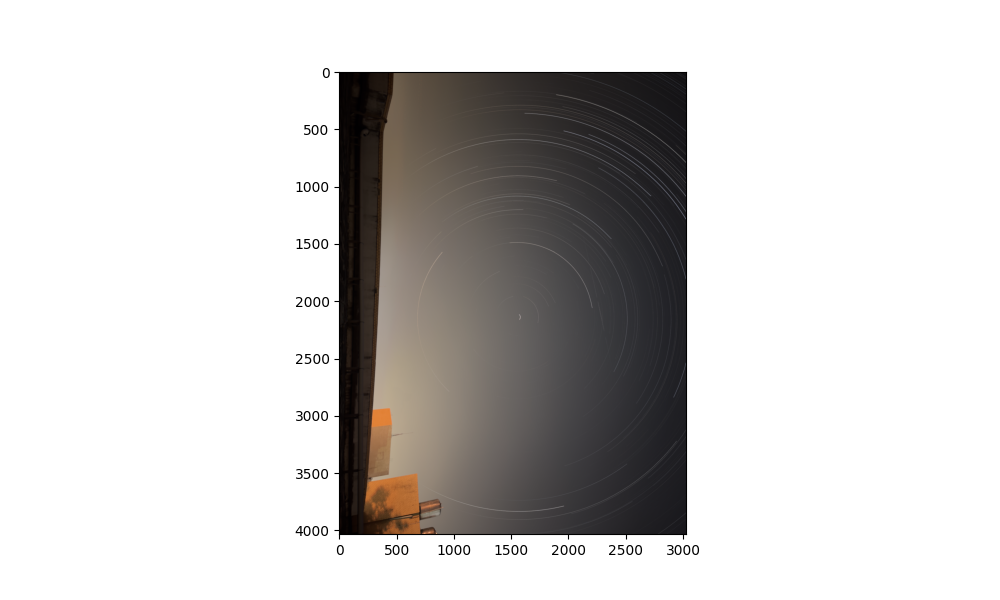

In [109]:
img_normal_rail = overlay_normal_rail(
    img_paths, 
    img_shape
)

print_img(img_normal_rail)

In [110]:
tiff.imwrite(
    os.path.join(output_path, f"{output_name}_Normal_Rail.tif"), # 修正副檔名寫法
    img_normal_rail.astype(np.float32), 
    photometric='rgb', 
    compression='zlib'
)

## Get The Background

In [96]:
def overlay_background(img_paths, img_shape):
    output_img = np.zeros(img_shape, dtype=np.float32)
    for img in tqdm(img_paths):
        img_raw = read_image(img)
        np.add(output_img, img_raw, out=output_img)
    return output_img/len(img_paths)

100%|██████████| 970/970 [01:07<00:00, 14.29it/s]


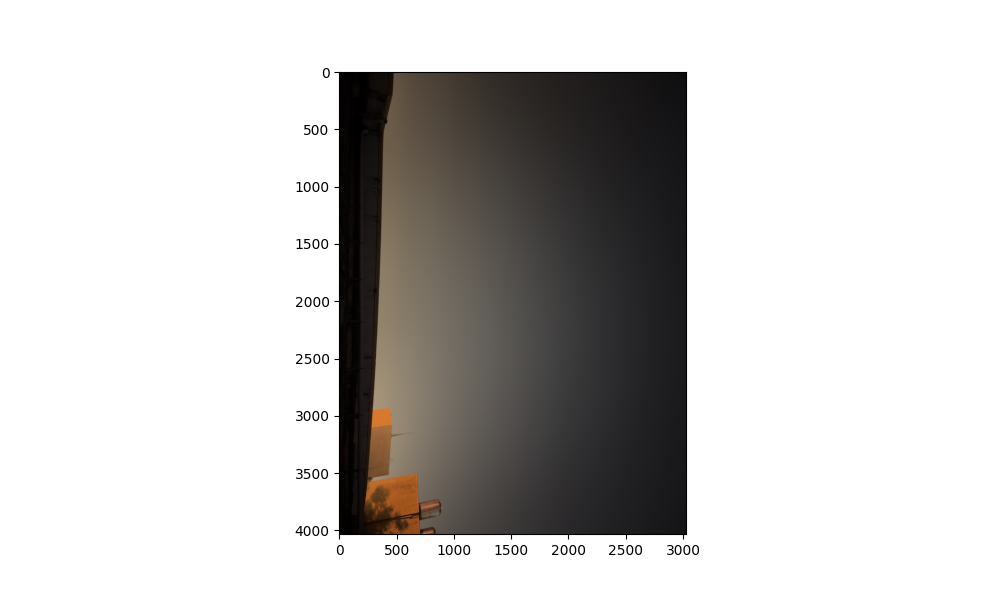

In [97]:
img_backgorund = overlay_background(
    img_paths,
    img_shape
)

print_img(img_backgorund)

In [98]:
img_to_save = (img_backgorund * 255).clip(0, 255).astype(np.uint8)
img_to_save = cv2.cvtColor(img_to_save, cv2.COLOR_RGB2BGR)

cv2.imwrite(
    os.path.join(output_path, f"{output_name}_Background.jpg"), 
    img_to_save, 
    [int(cv2.IMWRITE_JPEG_QUALITY), 95]
)

True

## Edit with Mask

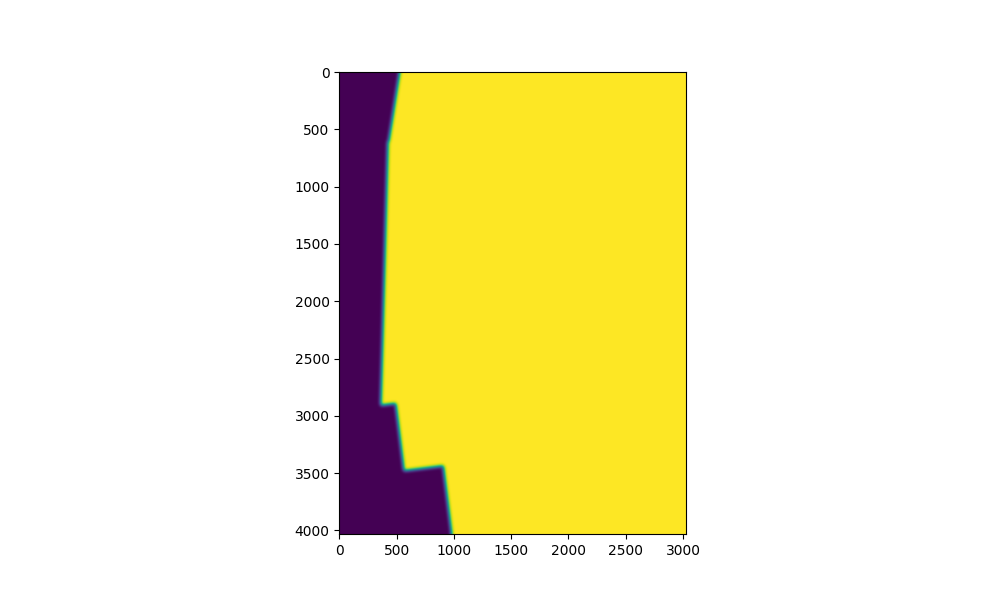

In [114]:
blur_size = 101

mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
mask_float = mask.astype(np.float32) / 255.0 # type: ignore
mask_float = cv2.GaussianBlur(mask_float, (blur_size, blur_size), 0)
mask_3d = mask_float[:, :, np.newaxis]

print_img(mask_3d)

In [125]:
def generate_scaled_canvas(img, scale, center_x, center_y, target_shape):
    height, width, _ = target_shape
    M = cv2.getRotationMatrix2D((center_x, center_y), 0, scale)
    canvas = cv2.warpAffine(img, M, (width, height), flags=cv2.INTER_LINEAR)
    
    return canvas

def overlay_rotating_rail(img_paths, img_shape, center_x, center_y):
    count = len(img_paths)
    star_trail_sum = np.zeros(img_shape, dtype=np.float32)
    ground_sum = np.zeros(img_shape, dtype=np.float32)

    for ind, picture in tqdm(enumerate(img_paths), total=count):
        n_img = read_image(picture)
        star_img = n_img*mask_3d
        ground_img = n_img*(1-mask_3d)

        current_scale = 1.0 - (ind / (count*3))
        
        height, width, _ = img_shape
        M = cv2.getRotationMatrix2D((center_x, center_y), 0, current_scale)
        canvas = cv2.warpAffine(star_img, M, (width, height), flags=cv2.INTER_LINEAR)

        star_trail_sum = np.maximum(canvas, star_trail_sum)
        ground_sum = np.add(ground_img, ground_sum)

    final_img = star_trail_sum+(ground_sum/count)

    return final_img

100%|██████████| 1246/1246 [02:40<00:00,  7.76it/s]


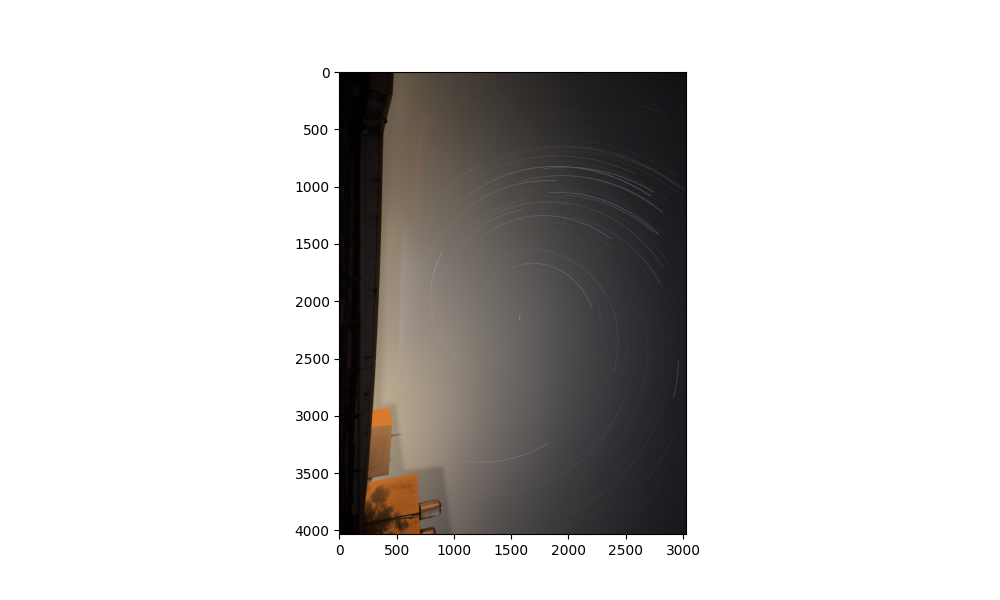

In [126]:
img_rotating = overlay_rotating_rail(
    img_paths, img_shape, 
    center_x=1557, # 你想要縮放的中心點 X 座標 (像素)
    center_y=2138  # 你想要縮放的中心點 Y 座標 (像素)
)

print_img(img_rotating)

In [127]:
tiff.imwrite(
    os.path.join(output_path, f"{output_name}_Rotating_Rail.tif"), # 修正副檔名寫法
    img_rotating.astype(np.float32), 
    photometric='rgb', 
    compression='zlib'
)